In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv("datasets/dp_lms_student_analytics_dataset.csv")
data


,StudentID,StudentName,Gender,Age,City,Course,Instructor,EnrollmentDate,Batch,CourseFee,...,AttendancePercentage,AssignmentScore,QuizScore,FinalScore,CourseProgress,StudyHoursPerWeek,LoginCount,CertificateIssued,StudentStatus,Revenue
0,1,Bikash Karki,Male,18,Pokhara,Advanced Excel,Sanjeev Shrestha,2025-03-31,AI-02,3000,...,93,90,72,81,100,19,30,Yes,Inactive,3000
1,2,Nabin Rai,Male,24,Butwal,MERN Stack,Manish Basnet,2026-03-09,AI-01,7000,...,84,63,76,69,79,5,50,No,Inactive,7000
2,3,Asmita Thapa,Female,24,Pokhara,Digital Marketing,Manish Basnet,2025-10-28,AI-02,4000,...,77,79,64,74,69,4,114,No,Active,4000
3,4,Nabin Basnet,Female,20,Itahari,Python with AI/ML,Sanjeev Shrestha,2026-01-15,AI-02,5000,...,79,62,84,75,74,14,39,No,Active,5000
4,5,Sita Basnet,Female,24,Janakpur,Advanced Excel,Samriddha Pathak,2025-10-02,FLT-01,3000,...,68,97,99,88,70,10,22,No,Active,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Prakash Karki,Male,30,Kathmandu,Python with AI/ML,Manish Basnet,2025-12-18,MRN-01,5000,...,71,95,82,84,73,6,46,No,Inactive,5000
496,497,Gita Basnet,Male,18,Pokhara,UI/UX,Sanjeev Shrestha,2026-04-28,MRN-01,4500,...,73,76,58,71,67,19,99,No,Inactive,4500
497,498,Rohan Rai,Male,24,Kathmandu,MERN Stack,Sanjeev Shrestha,2025-06-07,FLT-01,7000,...,62,97,84,86,60,18,87,No,Active,7000
498,499,Nabin Basnet,Male,20,Kathmandu,UI/UX,Samriddha Pathak,2025-09-13,AI-01,4500,...,73,59,67,67,69,12,110,No,Active,4500


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudentID             500 non-null    int64
 1   StudentName           500 non-null    str  
 2   Gender                500 non-null    str  
 3   Age                   500 non-null    int64
 4   City                  500 non-null    str  
 5   Course                500 non-null    str  
 6   Instructor            500 non-null    str  
 7   EnrollmentDate        500 non-null    str  
 8   Batch                 500 non-null    str  
 9   CourseFee             500 non-null    int64
 10  PaymentMethod         500 non-null    str  
 11  AttendancePercentage  500 non-null    int64
 12  AssignmentScore       500 non-null    int64
 13  QuizScore             500 non-null    int64
 14  FinalScore            500 non-null    int64
 15  CourseProgress        500 non-null    int64
 16  StudyHoursPerWeek  

In [6]:
data["EnrollmentDate"]=pd.to_datetime(data["EnrollmentDate"])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   StudentID             500 non-null    int64         
 1   StudentName           500 non-null    str           
 2   Gender                500 non-null    str           
 3   Age                   500 non-null    int64         
 4   City                  500 non-null    str           
 5   Course                500 non-null    str           
 6   Instructor            500 non-null    str           
 7   EnrollmentDate        500 non-null    datetime64[us]
 8   Batch                 500 non-null    str           
 9   CourseFee             500 non-null    int64         
 10  PaymentMethod         500 non-null    str           
 11  AttendancePercentage  500 non-null    int64         
 12  AssignmentScore       500 non-null    int64         
 13  QuizScore             500 non-n

In [9]:
data["month"]=data["EnrollmentDate"].dt.to_period("M")
data["month"]

0      2025-03
1      2026-03
2      2025-10
3      2026-01
4      2025-10
        ...   
495    2025-12
496    2026-04
497    2025-06
498    2025-09
499    2025-06
Name: month, Length: 500, dtype: period[M]

In [15]:
enroll=data.groupby("month").size()
enroll.index

PeriodIndex(['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06',
             '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12',
             '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06'],
            dtype='period[M]', name='month')

Text(0, 0.5, 'no of enrollment')

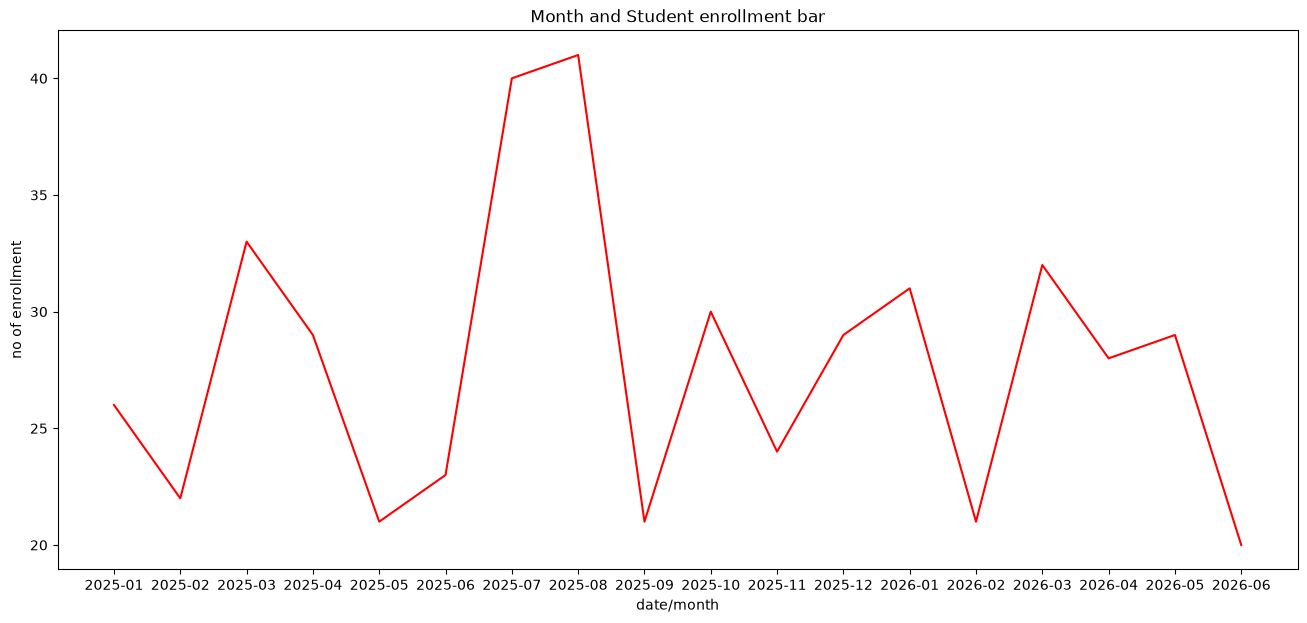

In [229]:
plt.figure(figsize=(16,7))
plt.title("Month and Student enrollment bar")

plt.plot(enroll.index.astype("str"),enroll.values,color="red")

plt.xlabel("date/month")
plt.ylabel("no of enrollment")

In [28]:
revenuet=data.groupby("month")["Revenue"].sum()
revenuet


month
2025-01    131000
2025-02    114500
2025-03    154000
2025-04    151500
2025-05    104000
2025-06    106000
2025-07    200000
2025-08    204500
2025-09    105500
2025-10    140000
2025-11    108000
2025-12    145500
2026-01    153000
2026-02     97000
2026-03    167000
2026-04    125000
2026-05    146000
2026-06     98500
Freq: M, Name: Revenue, dtype: int64

Text(0, 0.5, 'total revenue')

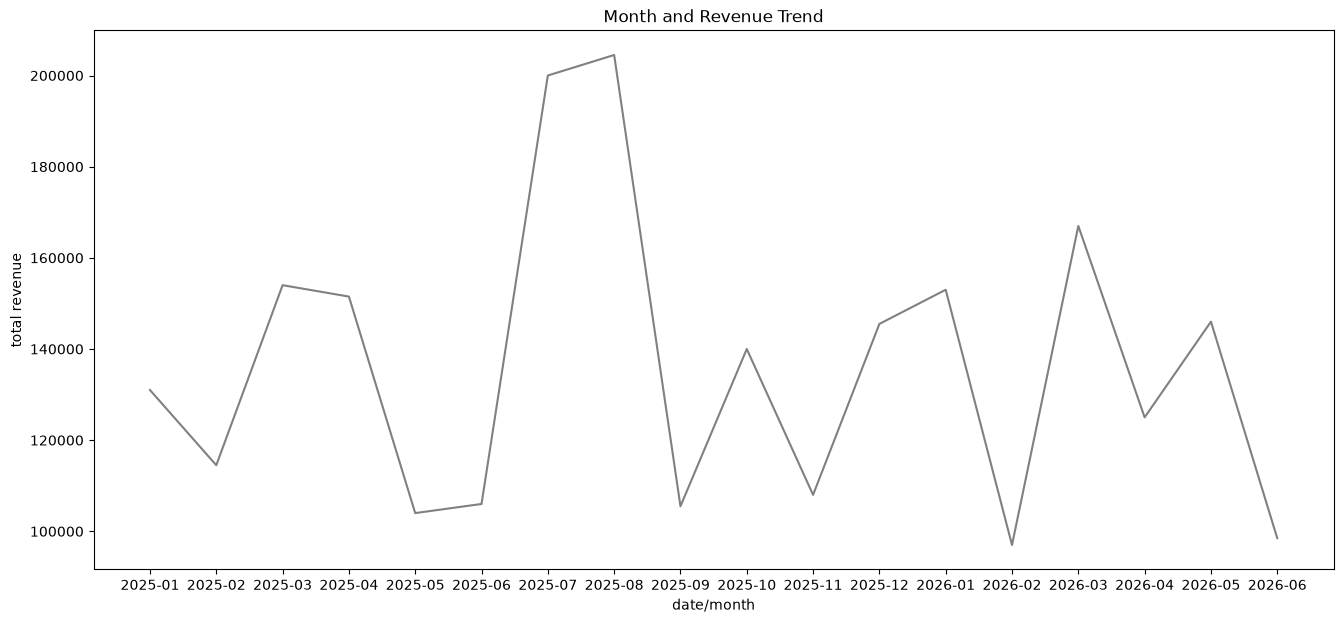

In [230]:
plt.figure(figsize=(16,7))
plt.title("Month and Revenue Trend")

plt.plot(revenuet.index.astype("str"),revenuet.values,color="grey")

plt.xlabel("date/month")
plt.ylabel("total revenue")

In [30]:
course_p=data.groupby("month")["CourseProgress"].mean()
course_p

month
2025-01    79.846154
2025-02    79.272727
2025-03    81.424242
2025-04    78.620690
2025-05    72.714286
2025-06    78.260870
2025-07    74.725000
2025-08    75.804878
2025-09    77.666667
2025-10    75.666667
2025-11    76.500000
2025-12    81.241379
2026-01    75.225806
2026-02    81.523810
2026-03    73.125000
2026-04    77.357143
2026-05    74.310345
2026-06    79.650000
Freq: M, Name: CourseProgress, dtype: float64

Text(0, 0.5, 'avg course progress')

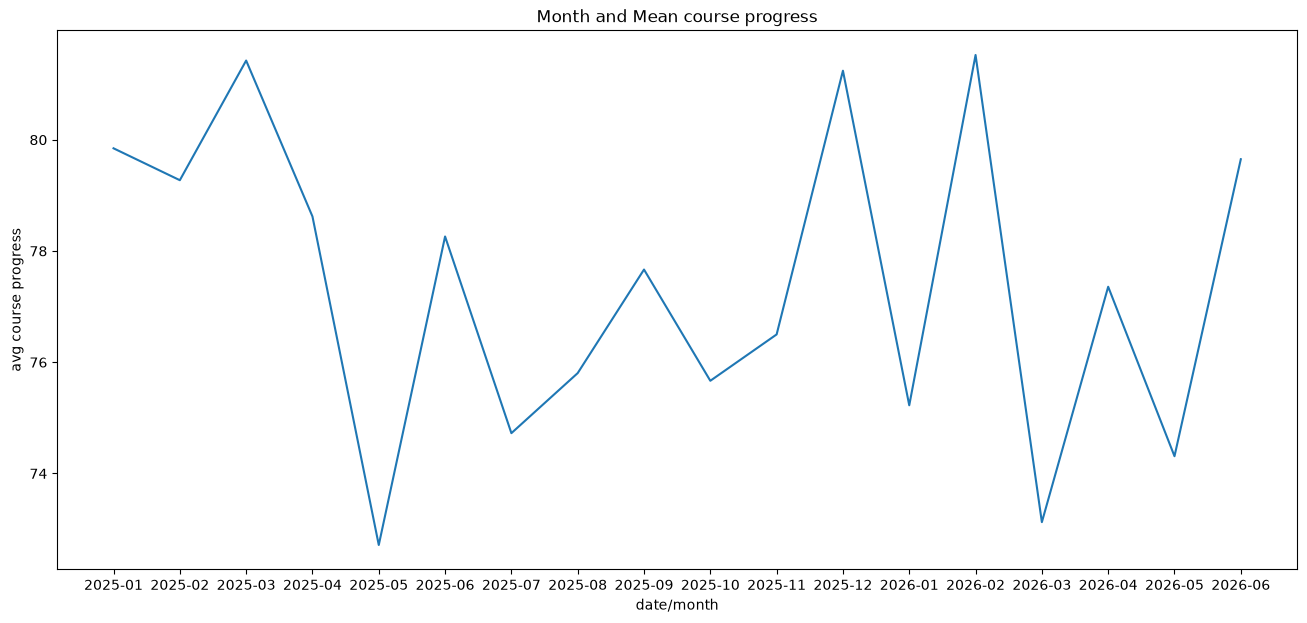

In [31]:
plt.figure(figsize=(16,7))
plt.title("Month and Mean course progress")

plt.plot(course_p.index.astype("str"),course_p.values)

plt.xlabel("date/month")
plt.ylabel("avg course progress")

In [32]:
att_m=data.groupby("month")['AttendancePercentage'].mean()
att_m

month
2025-01    79.115385
2025-02    79.454545
2025-03    80.454545
2025-04    77.344828
2025-05    72.095238
2025-06    78.260870
2025-07    75.600000
2025-08    77.707317
2025-09    77.904762
2025-10    75.366667
2025-11    75.375000
2025-12    82.310345
2026-01    75.870968
2026-02    81.904762
2026-03    73.968750
2026-04    80.785714
2026-05    76.137931
2026-06    80.150000
Freq: M, Name: AttendancePercentage, dtype: float64

Text(0, 0.5, 'avg attendence')

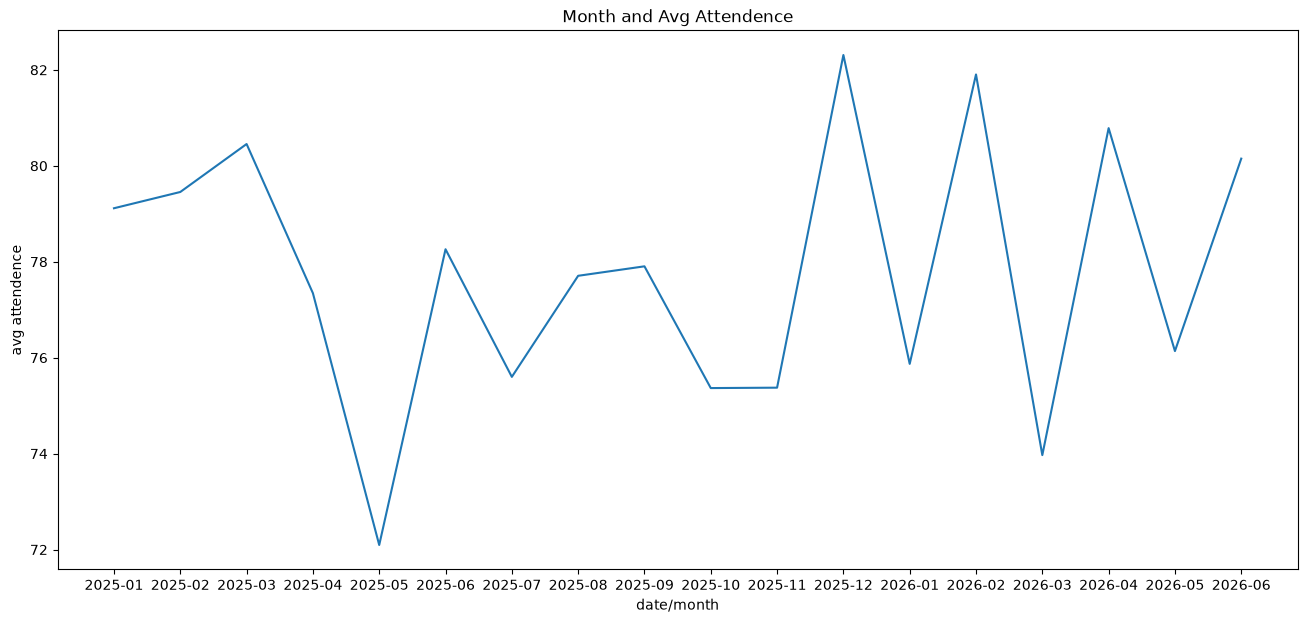

In [33]:
plt.figure(figsize=(16,7))
plt.title("Month and Avg Attendence")

plt.plot(att_m.index.astype("str"),att_m.values)

plt.xlabel("date/month")
plt.ylabel("avg attendence")

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   StudentID             500 non-null    int64         
 1   StudentName           500 non-null    str           
 2   Gender                500 non-null    str           
 3   Age                   500 non-null    int64         
 4   City                  500 non-null    str           
 5   Course                500 non-null    str           
 6   Instructor            500 non-null    str           
 7   EnrollmentDate        500 non-null    datetime64[us]
 8   Batch                 500 non-null    str           
 9   CourseFee             500 non-null    int64         
 10  PaymentMethod         500 non-null    str           
 11  AttendancePercentage  500 non-null    int64         
 12  AssignmentScore       500 non-null    int64         
 13  QuizScore             500 non-n

In [35]:
#bar for no of s in each course 
nec=data.groupby("Course").size()
nec

Course
Advanced Excel        90
Digital Marketing     74
Flutter               76
MERN Stack            68
Python with AI/ML    102
UI/UX                 90
dtype: int64

Text(0, 0.5, 'no of students')

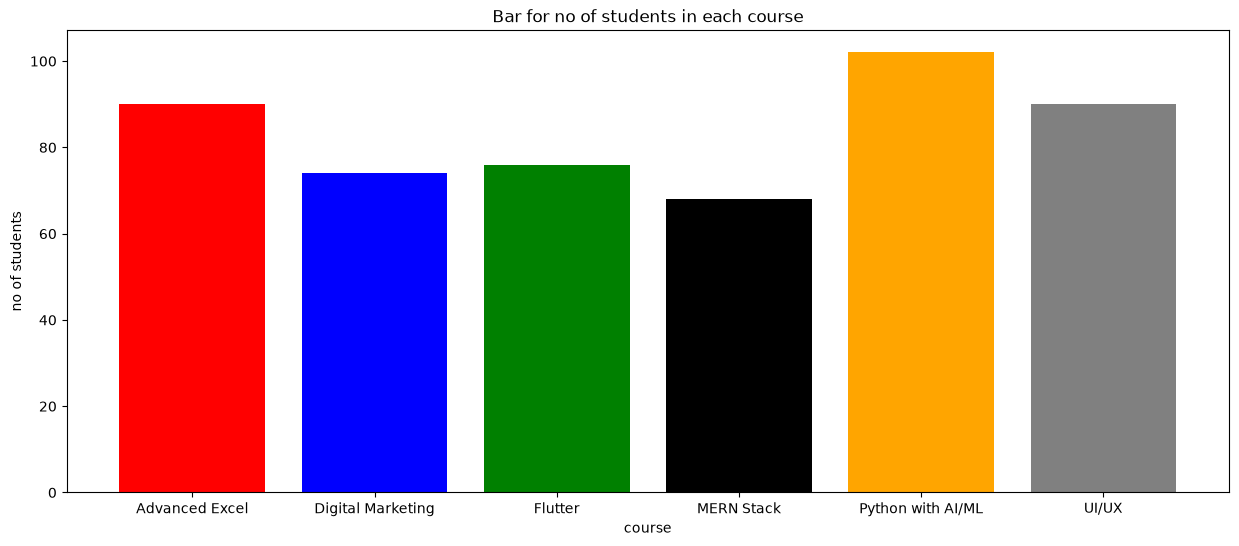

In [44]:
plt.figure(figsize=(15,6))
c=['red','blue','green','black','orange','grey']
plt.bar(nec.index,nec.values,color=c)
plt.title("Bar for no of students in each course")
plt.xlabel("course")
plt.ylabel("no of students")

In [45]:
reven_g=data.groupby("Course")["Revenue"].sum()
reven_g

Course
Advanced Excel       270000
Digital Marketing    296000
Flutter              494000
MERN Stack           476000
Python with AI/ML    510000
UI/UX                405000
Name: Revenue, dtype: int64

Text(0, 0.5, 'amoubt generated')

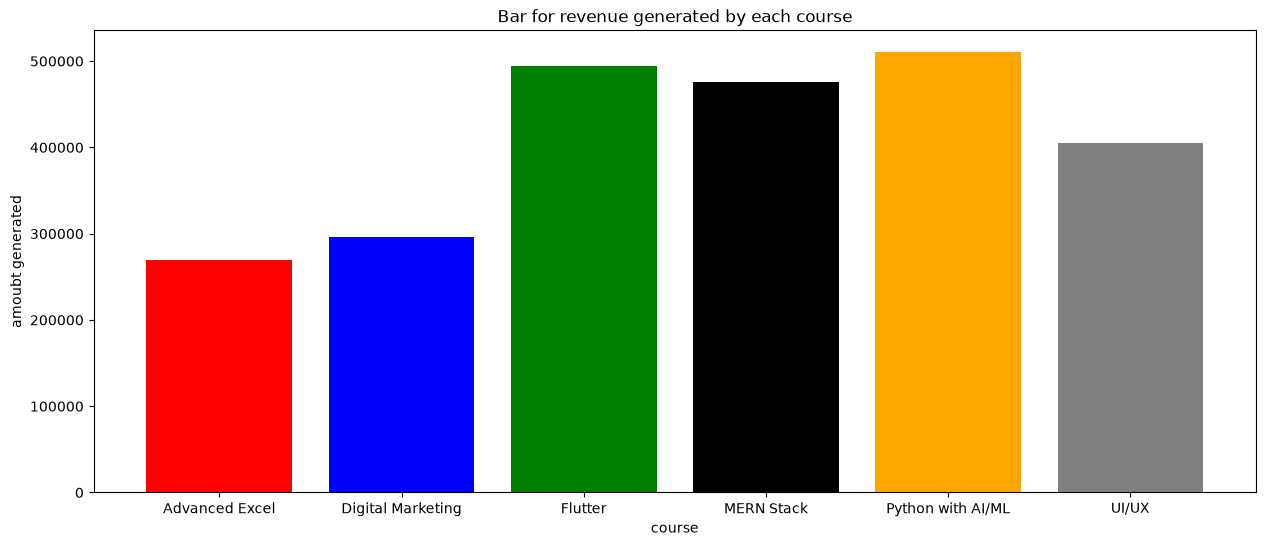

In [46]:
plt.figure(figsize=(15,6))
c=['red','blue','green','black','orange','grey']
plt.bar(reven_g.index,reven_g.values,color=c)
plt.title("Bar for revenue generated by each course")
plt.xlabel("course")
plt.ylabel("amoubt generated")

In [49]:
data.columns


Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

In [50]:
avgsc=data.groupby("Course")['FinalScore'].mean()
avgsc

Course
Advanced Excel       73.244444
Digital Marketing    73.878378
Flutter              74.184211
MERN Stack           73.691176
Python with AI/ML    74.558824
UI/UX                74.188889
Name: FinalScore, dtype: float64

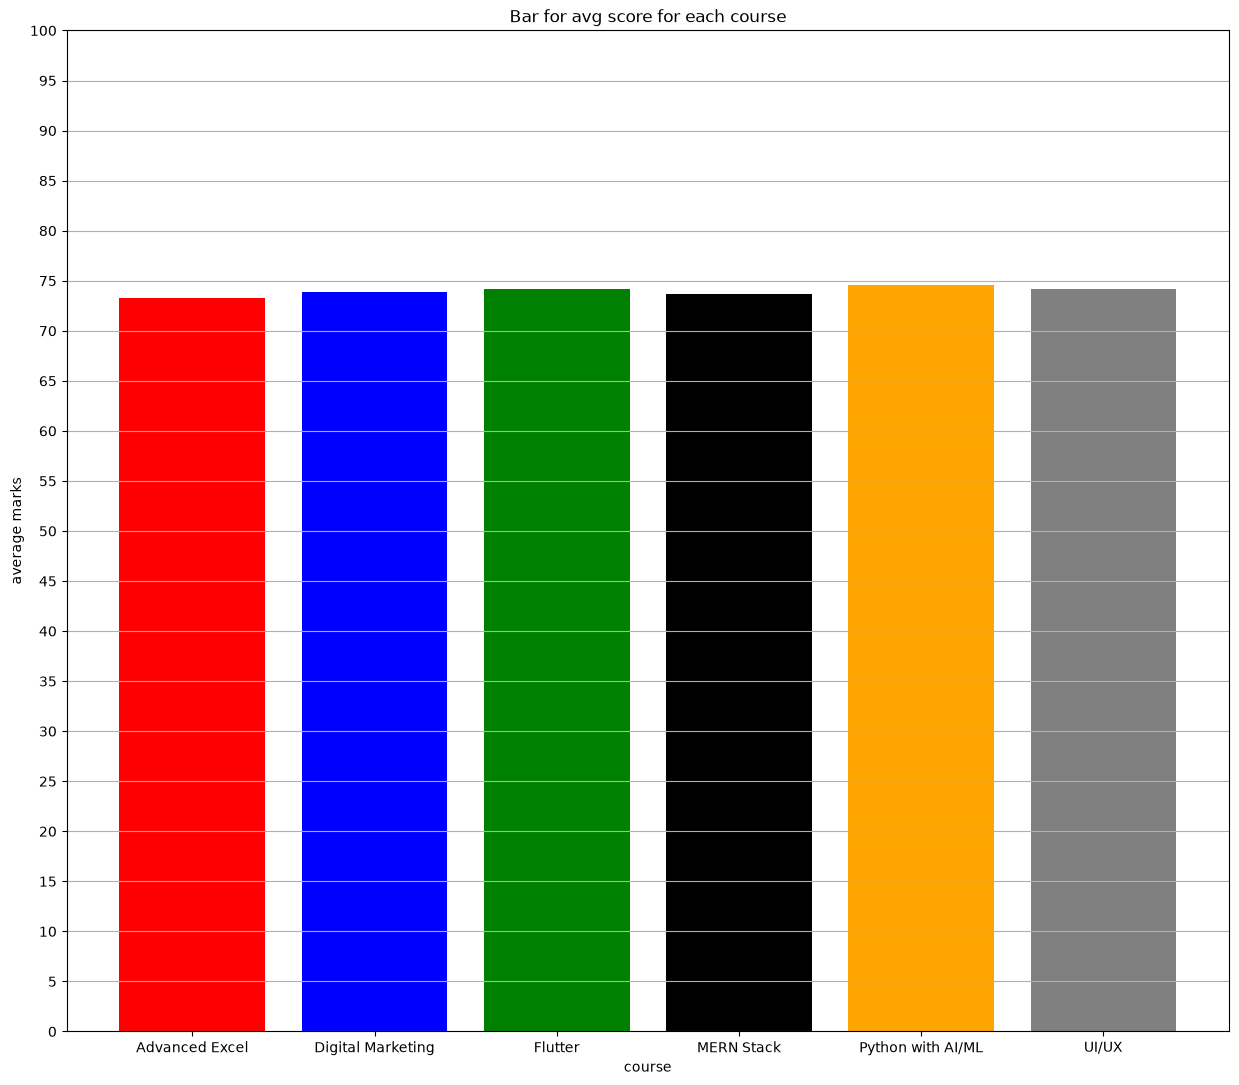

In [63]:
plt.figure(figsize=(15,13))
c=['red','blue','green','black','orange','grey']
plt.bar(avgsc.index,avgsc.values,color=c)
plt.title("Bar for avg score for each course")
plt.xlabel("course")
plt.ylabel("average marks")
plt.ylim(0,100) # learned to set 0 100 limit
plt.yticks(range(0,101,5))
plt.grid(axis="y")

In [58]:
avgabc=data.groupby("Course")['AttendancePercentage'].mean()
avgabc

Course
Advanced Excel       75.766667
Digital Marketing    79.648649
Flutter              77.013158
MERN Stack           77.000000
Python with AI/ML    78.274510
UI/UX                78.288889
Name: AttendancePercentage, dtype: float64

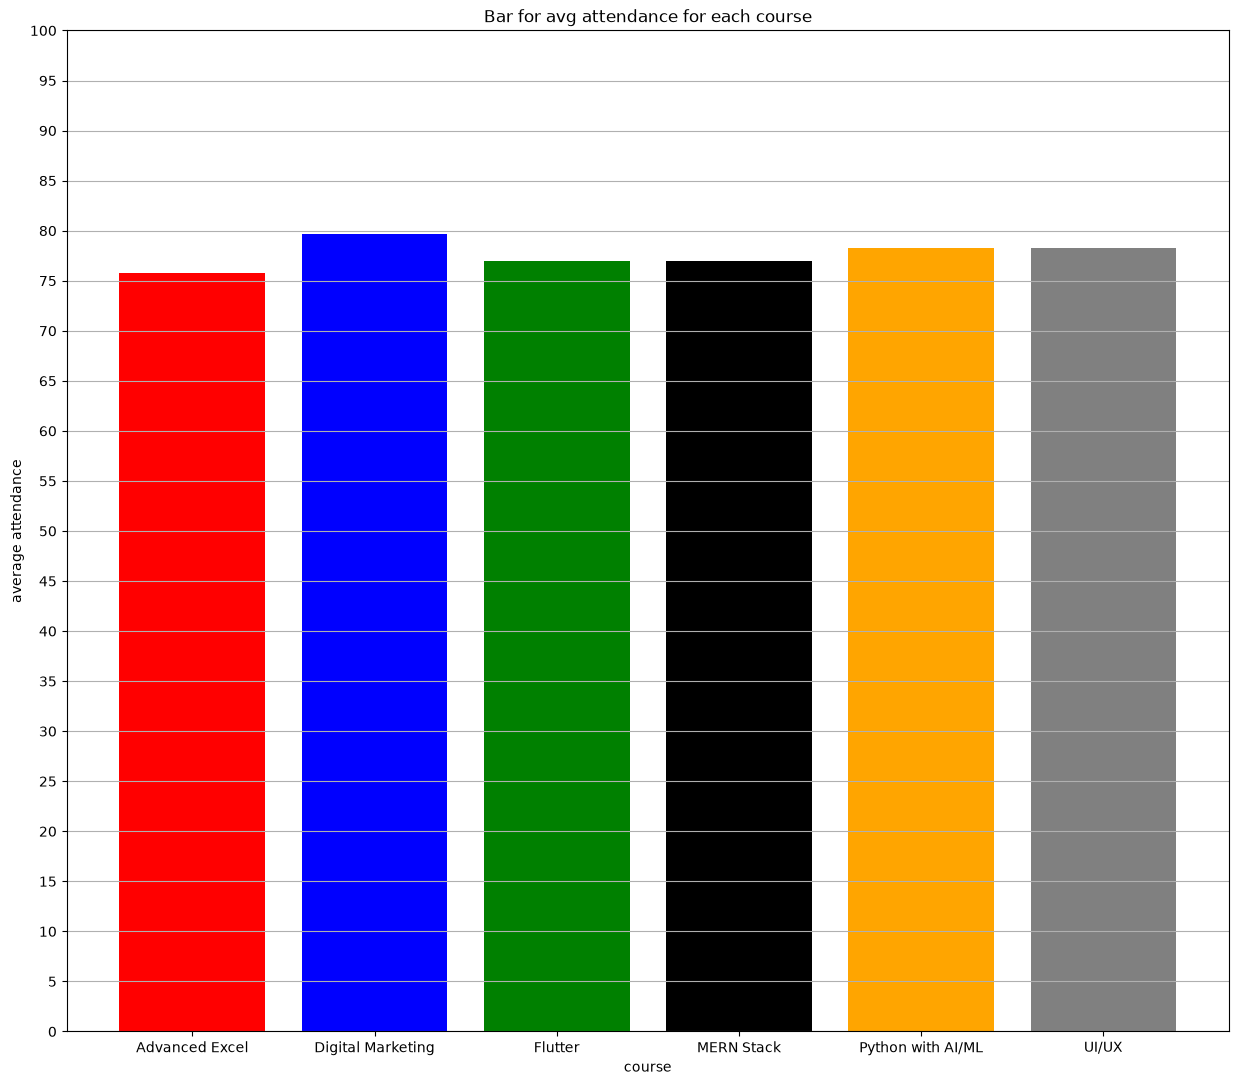

In [62]:
plt.figure(figsize=(15,13))
c=['red','blue','green','black','orange','grey']
plt.bar(avgabc.index,avgabc.values,color=c)
plt.title("Bar for avg attendance for each course")
plt.xlabel("course")
plt.ylabel("average attendance")
plt.ylim(0,100)
plt.yticks(range(0,101,5))
plt.grid(axis="y")

In [64]:
data.columns

Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

In [65]:
nsfc=data.groupby('City').size()
nsfc

City
Biratnagar    62
Butwal        49
Chitwan       62
Dharan        58
Itahari       59
Janakpur      75
Kathmandu     74
Pokhara       61
dtype: int64

Text(0, 0.5, 'no of students')

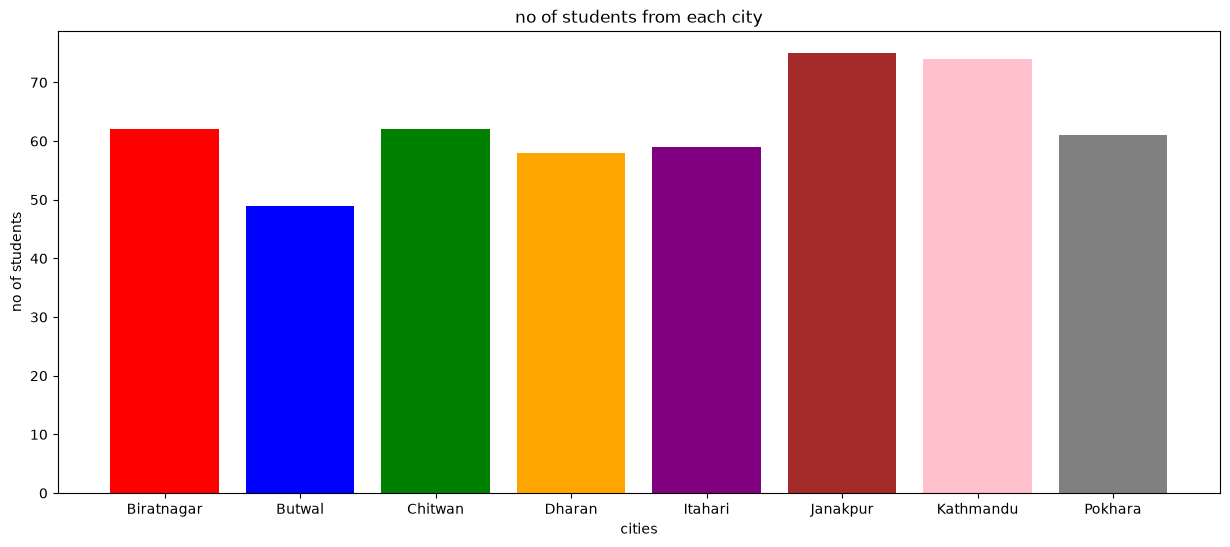

In [207]:
plt.figure(figsize=(15,6))
c = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'grey']
plt.bar(nsfc.index,nsfc.values,color=c)
plt.title("no of students from each city")
plt.xlabel("cities")
plt.ylabel("no of students")

In [70]:
data.columns

Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

In [72]:
nsuei=data.groupby('Instructor').size()
nsuei

Instructor
Ishan Kafle         129
Manish Basnet       106
Samriddha Pathak    146
Sanjeev Shrestha    119
dtype: int64

Text(0, 0.5, 'no of students')

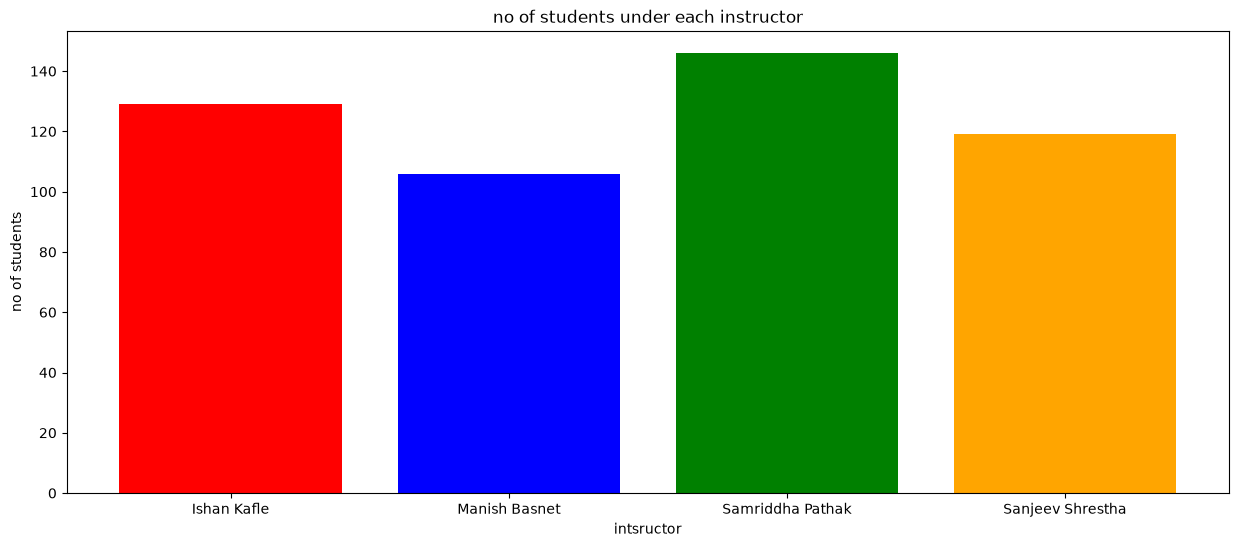

In [208]:
plt.figure(figsize=(15,6))
c = ['red', 'blue', 'green', 'orange']
plt.bar(nsuei.index,nsuei.values,color=c)
plt.title("no of students under each instructor")
plt.xlabel("intsructor")
plt.ylabel("no of students")

In [76]:
ttcbe=data.groupby('Course').size().sort_values(ascending=False).head(10)
ttcbe

Course
Python with AI/ML    102
Advanced Excel        90
UI/UX                 90
Flutter               76
Digital Marketing     74
MERN Stack            68
dtype: int64

([<matplotlib.axis.XTick at 0x1ece84934d0>,
 [Text(0, 0, '0'),
  Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100'),
  Text(110, 0, '110'),
  Text(120, 0, '120'),
  Text(130, 0, '130'),
  Text(140, 0, '140'),
  Text(150, 0, '150'),
  Text(160, 0, '160'),
  Text(170, 0, '170'),
  Text(180, 0, '180'),
  Text(190, 0, '190')])

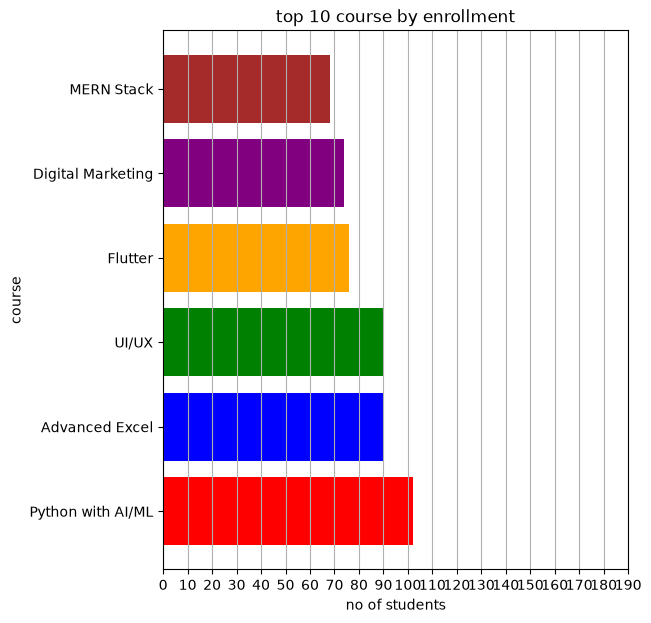

In [228]:
plt.figure(figsize=(6,7))
c = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
plt.barh(ttcbe.index,ttcbe.values,color=c)

plt.title("top 10 course by enrollment")
plt.xlabel("no of students")
plt.ylabel("course")
plt.grid(axis='x')
plt.xticks(range(0,200,10))

In [78]:
tti=data.groupby('Instructor').size().sort_values(ascending=False).head(10)
tti

Instructor
Samriddha Pathak    146
Ishan Kafle         129
Sanjeev Shrestha    119
Manish Basnet       106
dtype: int64

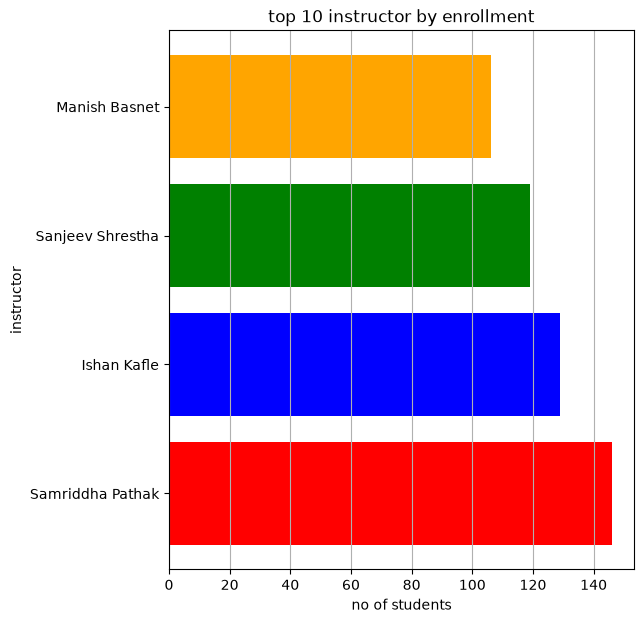

In [225]:
plt.figure(figsize=(6,7))
c = ['red', 'blue', 'green', 'orange']
plt.barh(tti.index,tti.values,color=c)
plt.title("top 10 instructor by enrollment")
plt.xlabel("no of students")
plt.ylabel("instructor")
plt.grid(axis="x")

In [84]:
# ttswhfs = data.groupby('StudentName')['FinalScore'].max().sort_values(ascending=False).head(10)
# ttswhfs

StudentName
Bikash Rai         97
Puja Karki         96
Hari Karki         94
Rohan Rai          94
Asmita Rai         93
Asmita Thapa       93
Aarav Rai          92
Bikash Adhikari    92
Puja Basnet        91
Ram Rai            91
Name: FinalScore, dtype: int64

In [85]:
idx = data.groupby('StudentName')['FinalScore'].idxmax()
ttswhfs = data.loc[idx, ['StudentName', 'Course', 'FinalScore']].sort_values(by='FinalScore', ascending=False).head(10)
ttswhfs

,StudentName,Course,FinalScore
458,Bikash Rai,MERN Stack,97
161,Puja Karki,Advanced Excel,96
358,Hari Karki,Digital Marketing,94
150,Rohan Rai,Python with AI/ML,94
197,Asmita Rai,Digital Marketing,93
89,Asmita Thapa,Python with AI/ML,93
322,Aarav Rai,Python with AI/ML,92
82,Bikash Adhikari,Flutter,92
229,Puja Basnet,UI/UX,91
105,Ram Rai,Python with AI/ML,91


In [101]:
ylabel=ttswhfs[["StudentName","Course"]].values
label = []
for i, j in ylabel:
    label.append(i + "-" + j)

    

([<matplotlib.axis.XTick at 0x1ecdc982c10>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

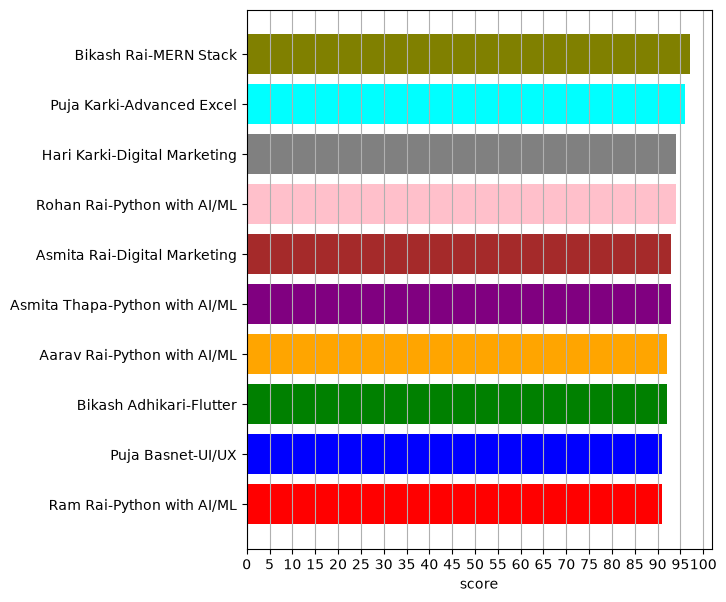

In [221]:
plt.figure(figsize=(6,7))
c = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'grey', 'cyan', 'olive']
plt.barh(label[::-1],ttswhfs["FinalScore"].values[::-1],color=c)

plt.grid(axis="x")
plt.xlabel("score")
plt.xticks(range(0,101,5))

In [105]:
data.columns

Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

In [106]:
s=data['CourseFee'].values
s

array([3000, 7000, 4000, 5000, 3000, 3000, 3000, 5000, 4000, 4000, 5000,
       3000, 3000, 4500, 5000, 4000, 4000, 5000, 7000, 5000, 4000, 5000,
       7000, 5000, 3000, 4000, 6500, 3000, 4500, 3000, 4500, 4500, 5000,
       6500, 3000, 5000, 4500, 5000, 4000, 3000, 6500, 3000, 5000, 4500,
       4000, 3000, 4500, 3000, 4500, 6500, 3000, 6500, 4500, 5000, 6500,
       3000, 4000, 4000, 5000, 5000, 6500, 4000, 5000, 7000, 3000, 7000,
       4000, 4500, 4500, 6500, 3000, 6500, 7000, 5000, 4500, 5000, 5000,
       4000, 7000, 6500, 4500, 6500, 6500, 5000, 4000, 7000, 4000, 4500,
       3000, 5000, 7000, 6500, 3000, 5000, 6500, 7000, 5000, 6500, 3000,
       4000, 4000, 6500, 4000, 3000, 6500, 5000, 4500, 6500, 7000, 4000,
       5000, 5000, 4000, 6500, 6500, 5000, 5000, 6500, 3000, 5000, 4500,
       4000, 7000, 3000, 7000, 5000, 5000, 5000, 5000, 4000, 4500, 3000,
       4000, 6500, 4000, 3000, 4000, 4500, 3000, 3000, 5000, 3000, 4500,
       4000, 5000, 4500, 4000, 4500, 4000, 6500, 50

In [118]:
print(s.min())
print(s.max())

3000
7000


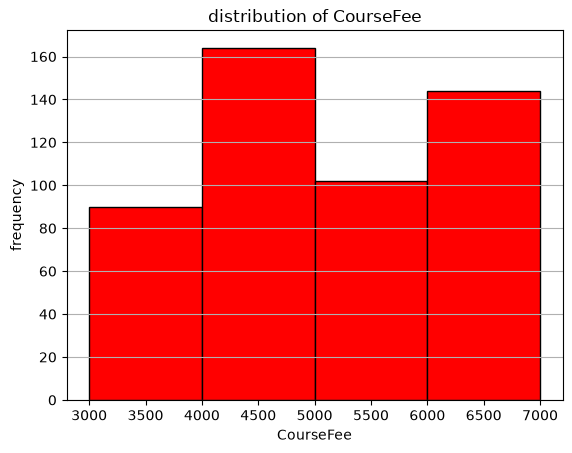

In [129]:
a=[3000,4000,5000,6000,7000]
plt.hist(s,color="red",bins=a,edgecolor='black')
plt.xlabel("CourseFee")
plt.ylabel("frequency")
plt.title('distribution of CourseFee')
plt.grid(axis="y")

In [154]:
a=data['AttendancePercentage'].values
ass_s=data['AssignmentScore'].values
q_s=data['QuizScore'].values
f_s=data['FinalScore'].values
c_p=data['CourseProgress'].values

([<matplotlib.axis.YTick at 0x1ecdc728f50>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90')])

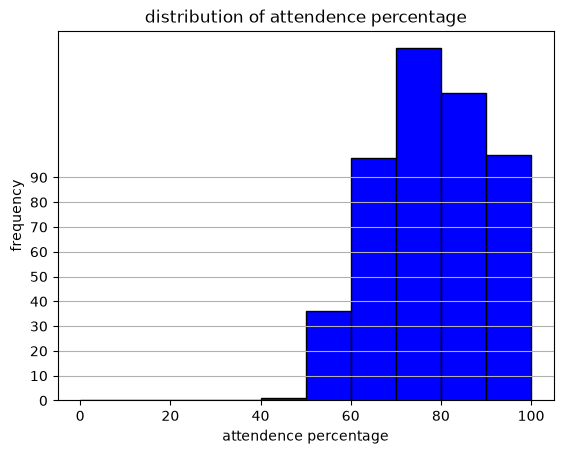

In [156]:
b=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(a,color="blue",bins=b,edgecolor='black')
plt.xlabel("attendence percentage")
plt.ylabel("frequency")
plt.title('distribution of attendence percentage')
plt.grid(axis="y")
plt.yticks(range(0,100,10))

In [138]:
ass_s.max()

np.int64(100)

([<matplotlib.axis.YTick at 0x1ecdc805310>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100'),
  Text(0, 110, '110'),
  Text(0, 120, '120'),
  Text(0, 130, '130'),
  Text(0, 140, '140'),
  Text(0, 150, '150'),
  Text(0, 160, '160'),
  Text(0, 170, '170'),
  Text(0, 180, '180'),
  Text(0, 190, '190'),
  Text(0, 200, '200')])

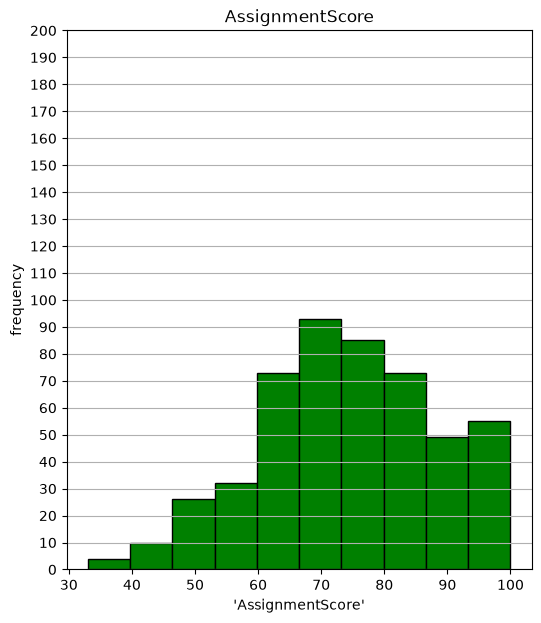

In [220]:
plt.figure(figsize=(6,7))
plt.hist(ass_s,color="green",bins=10,edgecolor='black')
plt.xlabel("'AssignmentScore'")
plt.ylabel("frequency")
plt.title("AssignmentScore")
plt.grid(axis="y")
plt.yticks(range(0,201,10))

In [136]:
q_s

array([ 72,  76,  64,  84,  99,  67,  32,  62, 100,  88,  73,  63,  95,
        42,  75,  62,  59,  67,  71,  72,  86, 100,  61,  82,  67,  65,
        56,  54,  39,  89,  99,  88,  67,  77,  39,  59,  52,  89, 100,
        95,  72,  69,  76,  64,  51,  82,  59,  33,  92,  81,  68,  64,
        83,  59,  61,  75,  74, 100,  68,  59, 100,  87,  99,  85,  85,
        64,  57,  54,  74,  58,  58,  58,  86,  94,  55,  73,  49,  75,
        87,  63,  80,  81,  83,  79,  85, 100,  63,  71,  74,  94,  77,
        57,  88,  61,  80,  58,  62,  62,  94, 100,  64,  84,  58,  67,
        86,  84,  30,  45,  76,  77,  93,  61,  61,  47,  92,  80,  69,
       100,  77,  83,  92,  43,  80,  73,  61,  27,  75, 100,  71,  77,
        70,  71,  80,  92,  41,  72,  43,  70,  68,  63,  61,  62,  68,
        68,  68,  42,  66,  64,  63,  98,  80,  53,  78,  57,  68,  82,
        82,  58,  60,  70,  51,  95,  93,  48,  90,  64,  78,  77,  73,
       100,  79,  51,  92,  95,  38,  90,  56,  64,  74,  76,  8

([<matplotlib.axis.YTick at 0x1ece63ae210>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100'),
  Text(0, 110, '110'),
  Text(0, 120, '120'),
  Text(0, 130, '130'),
  Text(0, 140, '140'),
  Text(0, 150, '150'),
  Text(0, 160, '160'),
  Text(0, 170, '170'),
  Text(0, 180, '180'),
  Text(0, 190, '190'),
  Text(0, 200, '200')])

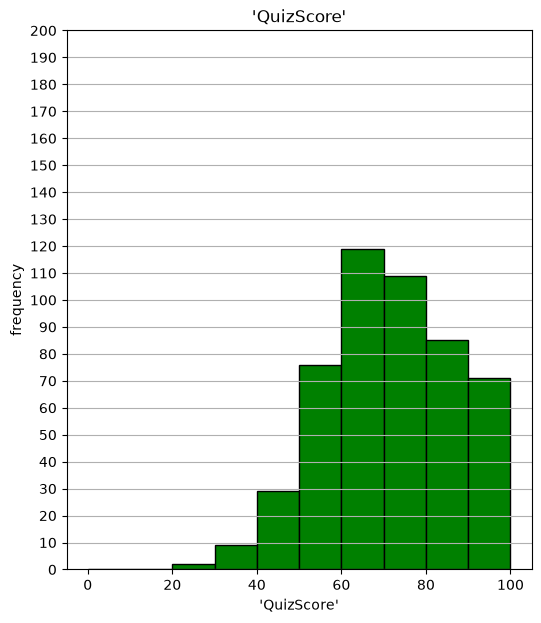

In [212]:
plt.figure(figsize=(6,7))
b=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(q_s,color="green",bins=b,edgecolor='black')
plt.xlabel("'QuizScore'")
plt.ylabel("frequency")
plt.title("'QuizScore'")
plt.grid(axis="y")
plt.yticks(range(0,201,10))

([<matplotlib.axis.YTick at 0x1ece65c2e90>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100'),
  Text(0, 110, '110'),
  Text(0, 120, '120'),
  Text(0, 130, '130'),
  Text(0, 140, '140'),
  Text(0, 150, '150'),
  Text(0, 160, '160'),
  Text(0, 170, '170'),
  Text(0, 180, '180'),
  Text(0, 190, '190'),
  Text(0, 200, '200')])

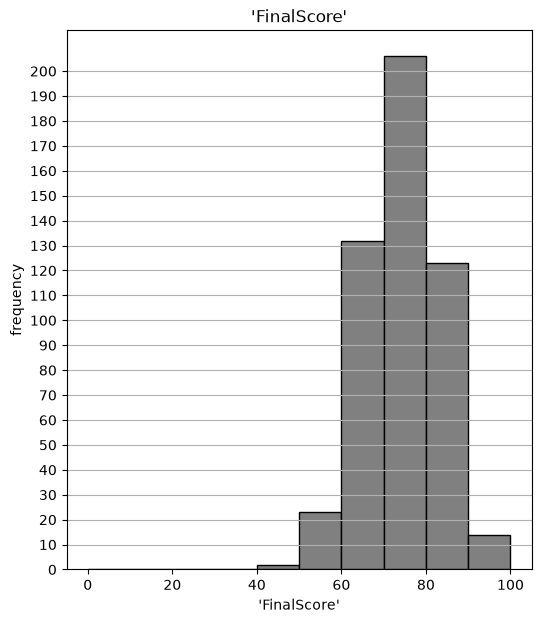

In [213]:
plt.figure(figsize=(6,7))
b=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(f_s,color="grey",bins=b,edgecolor='black')
plt.xlabel("'FinalScore'")
plt.ylabel("frequency")
plt.title("'FinalScore'")
plt.grid(axis="y")
plt.yticks(range(0,201,10))

([<matplotlib.axis.YTick at 0x1ece6667b10>,
 [Text(0, 0, '0'),
  Text(0, 10, '10'),
  Text(0, 20, '20'),
  Text(0, 30, '30'),
  Text(0, 40, '40'),
  Text(0, 50, '50'),
  Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100'),
  Text(0, 110, '110'),
  Text(0, 120, '120'),
  Text(0, 130, '130'),
  Text(0, 140, '140'),
  Text(0, 150, '150'),
  Text(0, 160, '160'),
  Text(0, 170, '170'),
  Text(0, 180, '180'),
  Text(0, 190, '190'),
  Text(0, 200, '200')])

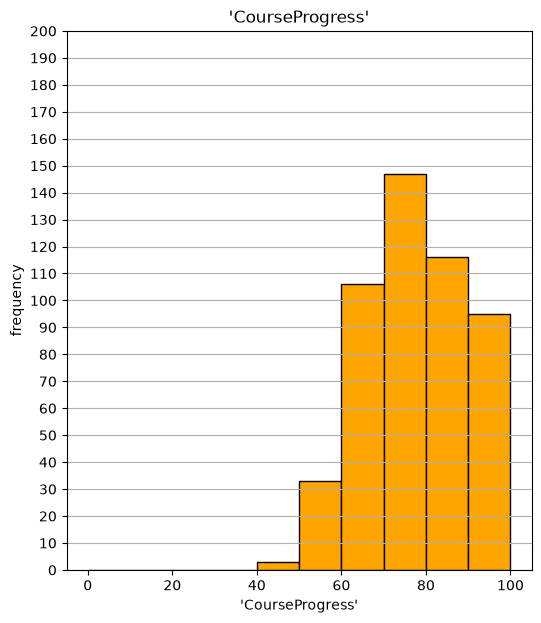

In [214]:
plt.figure(figsize=(6,7))
b=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(c_p,color="orange",bins=b,edgecolor='black')
plt.xlabel("'CourseProgress'")
plt.ylabel("frequency")
plt.title("'CourseProgress'")
plt.grid(axis="y")
plt.yticks(range(0,201,10))

In [157]:
data.columns

Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

In [167]:
s_dc=data.groupby('Course').size()

s_dg=data.groupby('Gender').size()
p_m=data.groupby('PaymentMethod').size()
s_t=data.groupby('StudentStatus').size()
cert=data.groupby('CertificateIssued').size()

In [168]:
cert

CertificateIssued
No     306
Yes    194
dtype: int64

Text(0.5, 1.0, 'Pie chart of student distribution per courses')

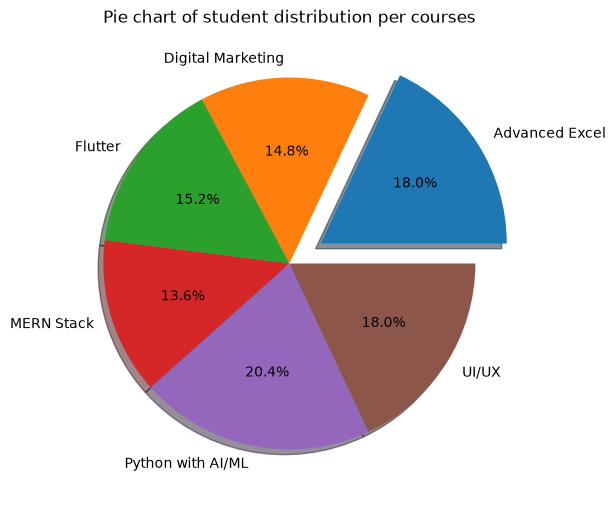

In [215]:
plt.figure(figsize=(6,7))
plt.pie(s_dc.values,labels=s_dc.index,explode=(0.2,0,0,0,0,0),shadow=True, autopct='%1.1f%%')
plt.title("Pie chart of student distribution per courses")

Text(0.5, 1.0, 'Pie chart of student distribution per gender')

<Figure size 600x700 with 0 Axes>

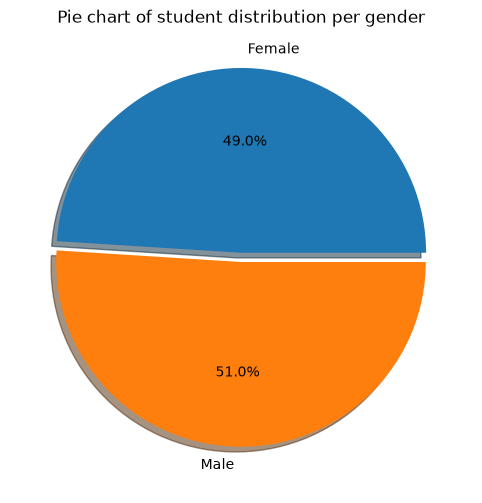

In [216]:
plt.figure(figsize=(6,7))
plt.figure(figsize=(6,6))
plt.pie(s_dg.values,labels=s_dg.index,explode=(0.05,0),shadow=True, autopct='%1.1f%%')
plt.title("Pie chart of student distribution per gender")

Text(0.5, 1.0, 'Pie chart of payment method distribution')

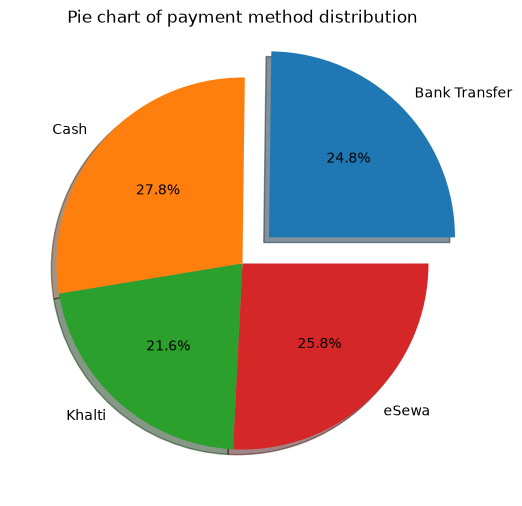

In [217]:
plt.figure(figsize=(6,7))
plt.pie(p_m.values,labels=p_m.index,explode=(0.2,0,0,0),shadow=True, autopct='%1.1f%%')
plt.title("Pie chart of payment method distribution")

Text(0.5, 1.0, 'Pie chart of student status ')

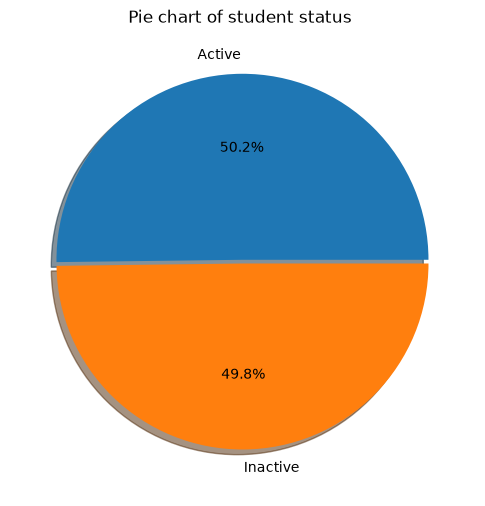

In [218]:
plt.figure(figsize=(6,7))
plt.pie(s_t.values,labels=s_t.index,explode=(0.02,0),shadow=True, autopct='%1.1f%%')
plt.title("Pie chart of student status ")

Text(0.5, 1.0, 'Pie chart of certificate issution ')

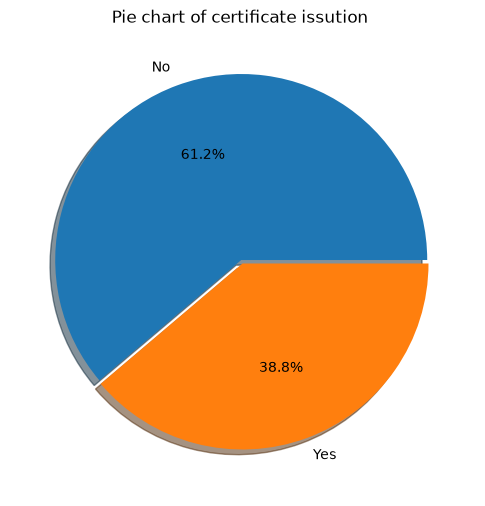

In [219]:
plt.figure(figsize=(6,7))
plt.pie(cert.values,labels=cert.index,explode=(0.02,0),shadow=True, autopct='%1.1f%%')
plt.title("Pie chart of certificate issution ")

In [191]:
data.columns

Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue', 'month'],
      dtype='str')

Text(0, 0.5, 'Final Score')

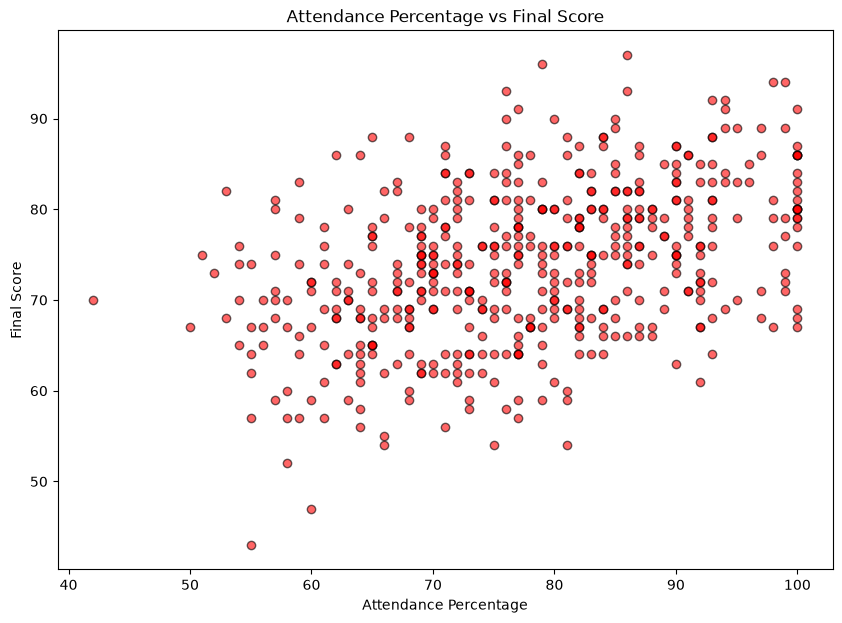

In [192]:
plt.figure(figsize=(10,7))
plt.scatter(data["AttendancePercentage"], data["FinalScore"], alpha=0.6, color='red',edgecolor='black')
plt.title("Attendance Percentage vs Final Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final score')

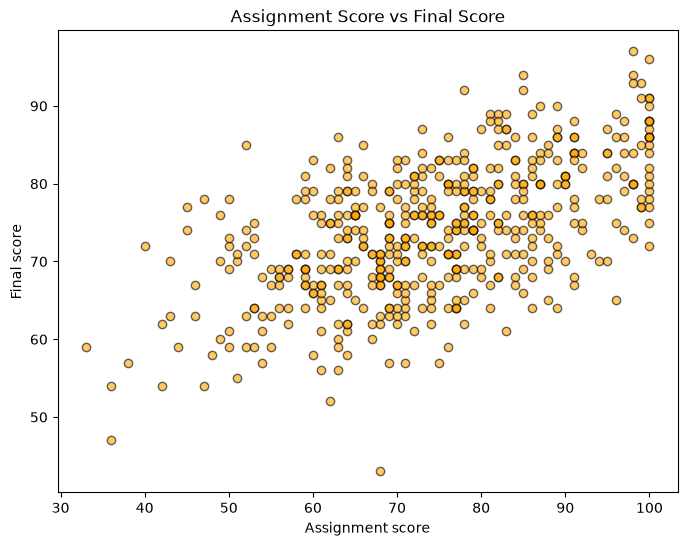

In [194]:
plt.figure(figsize=(8,6))
plt.scatter(data["AssignmentScore"], data["FinalScore"], alpha=0.6, color='orange',edgecolor="black")
plt.title("Assignment Score vs Final Score")
plt.xlabel("Assignment score")
plt.ylabel("Final score")

Text(0, 0.5, 'Final Score')

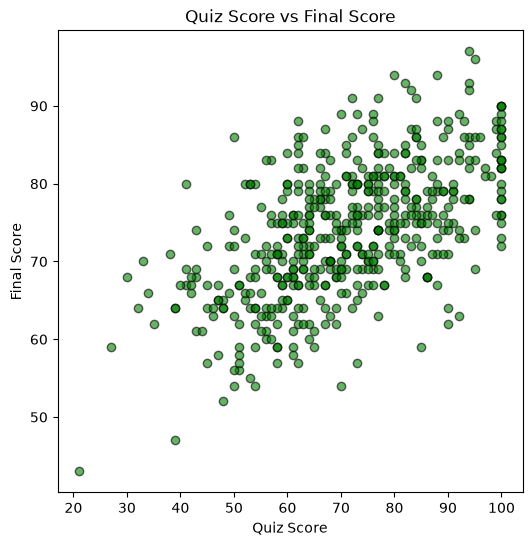

In [196]:
plt.figure(figsize=(6,6))
plt.scatter(data["QuizScore"], data["FinalScore"],edgecolor="black", alpha=0.6, color='green')
plt.title("Quiz Score vs Final Score")
plt.xlabel("Quiz Score")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final Score')

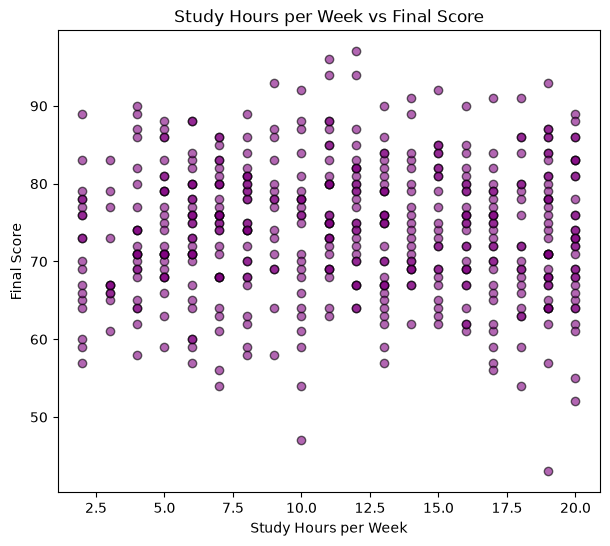

In [198]:
plt.figure(figsize=(7,6))
plt.scatter(data["StudyHoursPerWeek"], data["FinalScore"], alpha=0.6,edgecolor="black", color='purple')
plt.title("Study Hours per Week vs Final Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final Score')

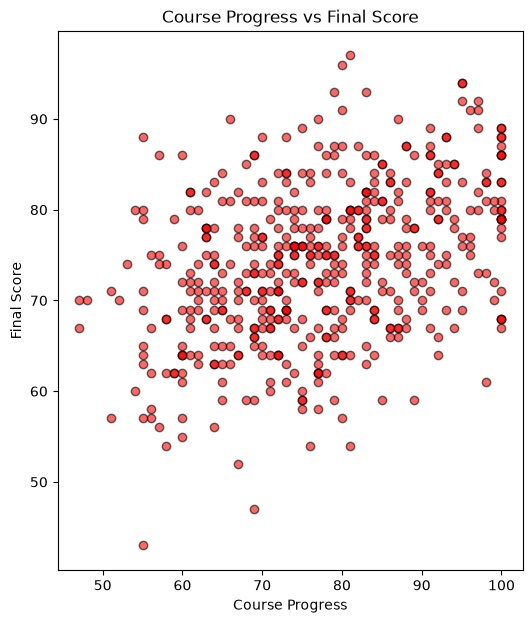

In [199]:
plt.figure(figsize=(6,7))
plt.scatter(data["CourseProgress"], data["FinalScore"], color='red', alpha=0.6,edgecolor="black")
plt.title("Course Progress vs Final Score")
plt.xlabel("Course Progress")
plt.ylabel("Final Score")

Text(0, 0.5, 'Course Progress')

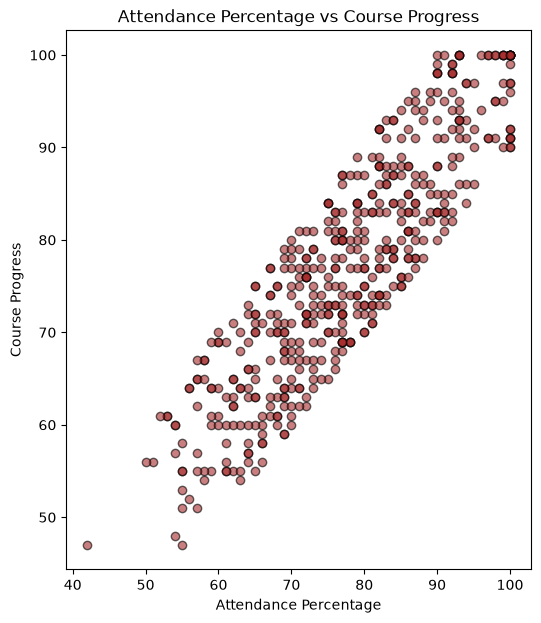

In [200]:
plt.figure(figsize=(6,7))
plt.scatter(data["AttendancePercentage"], data["CourseProgress"], color='brown', alpha=0.6,edgecolor="black")
plt.title("Attendance Percentage vs Course Progress")
plt.xlabel("Attendance Percentage")
plt.ylabel("Course Progress")